# Dataset Assembly Notebook

This notebook assembles the train/val/test splits for YOLOv11 object detection training on compound figure separation. It documents **three versions** of the splitting strategy—each iteration addressing shortcomings discovered through training and validation.

### How to use this notebook
- **Purpose:** Assemble train/val/test splits for the all-classes YOLO dataset using synthetic + real compounds.
- **Prerequisites:** Synthetic outputs under `../../dataset/03_intermediate/SCI-3000_synthetic-generated` and real compounds under `../../dataset/03_intermediate/SCI-3000_real-compound` (with labels from Label Studio).
- **Steps:** Update paths if needed, then run cells in order; the helper clears and rebuilds `../../dataset/04_all_classes`.
- **Output:** Images/labels in `04_all_classes/{train,val,test}` plus a `data.yaml`.
- **Versioning note:** Keep the latest curated splits (`04_all_classes`, `05_selected_classes`, `06_compound_chart_splitter`); archive older experimental outputs.

---

### Class Schema (10 classes)
| ID | Class Name      | Description                                                    |
|----|-----------------|----------------------------------------------------------------|
| 0  | Chart           | Scientific plots, graphs, bar charts, etc.                    |
| 1  | Illustration    | Diagrams, schematics, flowcharts                              |
| 2  | Image           | Photographs, micrographs, scans                               |
| 3  | Other           | Anything not fitting above categories                         |
| 4  | Shared Legend   | Legend shared across multiple subpanels                       |
| 5  | Shared Title    | Title spanning multiple subpanels                             |
| 6  | Shared X-Axis   | X-axis label shared across subpanels                          |
| 7  | Shared Y-Axis   | Y-axis label shared across subpanels                          |
| 8  | Subpanel        | Generic subpanel marker (fallback)                            |
| 9  | Table           | Tabular data embedded in compound figures                     |

---

## Evolution of Dataset Splits: V1 → V2 → V3

### V1: Baseline Sim2Real (archived in `03_Dataset_Assembly_old.ipynb`)

**Strategy:**
- Training: ALL synthetic + 70% real
- Validation: 15% real only (strict domain validation)
- Test: 15% real only

**Problem discovered:**  
Random splitting caused **severe class imbalance** in val/test. Classes 4–7 (Shared Legend/Title/X-Axis/Y-Axis) had near-zero presence in validation, and Table (class 9) had only 1 sample total. The YOLO model learned to ignore these rare classes entirely—validation loss looked fine but recall collapsed.

---

### V2: Stratified Split + Oversampling (archived)

**Fixes applied:**
1. **Stratified splitting** using `sklearn.train_test_split` with `stratify=stratify_group`
2. **Oversampling** rare classes in training: 25× for shared properties, 5× for subpanels
3. **Synthetic table injection** into val/test to avoid zero-table splits

**Remaining problem:**  
Shared axes/titles remained underrepresented because the *real data* simply didn't have enough examples. Oversampling existing samples only goes so far—we needed more diverse examples.

---

### V3: Plot-augmented Dataset (current version)

**Additional fix:**
- Injected **synthetically generated compound plots** (`SyntheticCompoundPlots/`) containing Shared Legend/Title/X/Y annotations. These are created by `CompoundPlotGenerator.py` using matplotlib.
- Increased val ratio to 25% to surface rare errors earlier during training.

**Sources:**
| Dataset                                | Usage                                    |
|----------------------------------------|------------------------------------------|
| `SCI-3000_synthetic-generated`         | Stitched single figures → train (+some val/test tables) |
| `SCI-3000_real-compound`               | Hand-labeled real papers → stratified split |
| `SyntheticCompoundPlots`               | Plot-focused synthetics with shared elements → train |

# Data Assembly V3: Stratified, Oversampled, and Plot-augmented

### Why V3 Works Better

| Issue in V1/V2                          | V3 Solution                                              |
|-----------------------------------------|----------------------------------------------------------|
| Zero shared-axis samples in val         | Plot-focused synthetics provide coverage                 |
| Table only in 1 real image              | Synthetic tables injected into all splits                |
| Random split breaks rarity distribution | Stratification preserves class proportions               |
| Rare classes ignored by model           | Oversampling forces model to learn them                  |
| Val loss misleading (rare classes gone) | Larger val ratio (25%) surfaces rare-class errors early  |

**Key insight:** When real data is scarce for certain classes, synthetic augmentation is not optional—it's essential. The model cannot learn what it never sees.

In [ ]:
import shutil
import random
import os
from pathlib import Path
from tqdm.notebook import tqdm  # Notebook-friendly progress bar
import yaml
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

## 1. Configuration & Paths

Define input directories for all data sources and configure oversampling factors. The key tuning knobs here are:

- **VERY_RARE_CLASSES** (4, 5, 6, 7): Shared legend/title/axes—almost never appear in real data
- **RARE_CLASSES** (8): Subpanel—appears but infrequently
- **Oversample factors**: Multiply occurrences in `train.txt` to balance the loss function

In [ ]:
# =============================================================================
# INPUT PATHS
# All paths relative to notebook location (src/notebooks/)
# =============================================================================

# 1. Synthetic Data: Stitched single figures from SCI-3000
SYNTH_DIR = Path("../../dataset/03_intermediate/SCI-3000_synthetic-generated")
SYNTH_IMG_DIR = SYNTH_DIR / "images"
SYNTH_LBL_DIR = SYNTH_DIR / "yolo-labels"  # Labels from the generator

# 2. Real Data: Hand-labeled compound figures from Label Studio
REAL_BASE_DIR = Path("../../dataset/03_intermediate/SCI-3000_real-compound")
REAL_IMG_DIR = REAL_BASE_DIR  # Images in root
REAL_LBL_DIR = REAL_BASE_DIR / "label-studio_export/labels"  # YOLO-format labels

# 3. Plot-focused Synthetic Data (V3 addition)
# Contains matplotlib-generated plots with shared axes/legends/titles
SYNTH_PLOT_DIR = Path("../../dataset/03_intermediate/SyntheticCompoundPlots")
SYNTH_PLOT_IMG_DIR = SYNTH_PLOT_DIR / "images"
SYNTH_PLOT_LBL_DIR = SYNTH_PLOT_DIR / "yolo-labels"

# =============================================================================
# OUTPUT TARGET
# =============================================================================
OUTPUT_DIR = Path("../../dataset/04_all_classes")

# =============================================================================
# SPLIT RATIOS (Real Data Only)
# V3 uses larger val ratio to surface rare-class errors earlier
# =============================================================================
VAL_RATIO = 0.25   # 25% validation (increased from 15% in V1/V2)
TEST_RATIO = 0.10  # 10% test
# Remaining 65% goes to Train

# Verify paths exist
print("Checking Inputs:")
print(f"  Synth Images:      {SYNTH_IMG_DIR.exists()}")
print(f"  Synth Labels:      {SYNTH_LBL_DIR.exists()}")
print(f"  Real Labels:       {REAL_LBL_DIR.exists()}")
print(f"  Synth Plot Images: {SYNTH_PLOT_IMG_DIR.exists()}")
print(f"  Synth Plot Labels: {SYNTH_PLOT_LBL_DIR.exists()}")

# =============================================================================
# OVERSAMPLING CONFIGURATION
# These factors determine how many times rare-class images repeat in train.txt
# =============================================================================
VERY_RARE_CLASSES = [4, 5, 6, 7]  # Shared Legend/Title/X-Axis/Y-Axis
RARE_CLASSES = [8]                 # Subpanel
VERY_OVERSAMPLE_FACTOR = 25        # 25x for shared elements (almost never in real data)
RARE_OVERSAMPLE_FACTOR = 5         # 5x for subpanels (infrequent but present)

Checking Inputs:
  Synth Images: True
  Synth Labels: True
  Real Labels:  True
  Synth Plot Images: True
  Synth Plot Labels: True


## 2. Helper Functions

Utility functions for:
1. **Directory management** – wipe and recreate output structure
2. **Image discovery** – find matching images across multiple directories (handles .jpg/.png/etc.)
3. **File copying** – copy image+label pairs to target splits with progress tracking

In [ ]:
def clear_and_create_dirs(base_path):
    """
    Wipe existing output folder and recreate the YOLO directory structure.
    
    Creates:
        base_path/
            images/
                train/
                val/
                test/
            labels/
                train/
                val/
                test/
    """
    if base_path.exists():
        print(f"Cleaning up old directory: {base_path}")
        shutil.rmtree(base_path)
    
    for split in ['train', 'val', 'test']:
        (base_path / "images" / split).mkdir(parents=True, exist_ok=True)
        (base_path / "labels" / split).mkdir(parents=True, exist_ok=True)
    print(f"Directory structure '{base_path.name}' created.")


def find_image(stem, search_dirs):
    """
    Search for an image file matching the given stem across multiple directories.
    
    Args:
        stem: Filename without extension (e.g., 'abc123-fig-0')
        search_dirs: List of Path objects to search in
        
    Returns:
        Path to found image, or None if not found
    """
    valid_exts = ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']
    for folder in search_dirs:
        if not folder.exists():
            continue
        for ext in valid_exts:
            p = folder / (stem + ext)
            if p.exists():
                return p
    return None


def copy_files(file_stems, search_img_dirs, src_lbl_dir, split_type, dataset_name="Real"):
    """
    Copy image+label pairs to the target split directory.
    
    Args:
        file_stems: List of filename stems to copy
        search_img_dirs: Directories to search for images
        src_lbl_dir: Directory containing label files
        split_type: 'train', 'val', or 'test'
        dataset_name: Display name for progress bar
        
    Returns:
        Number of successfully copied files
    """
    dest_img = OUTPUT_DIR / "images" / split_type
    dest_lbl = OUTPUT_DIR / "labels" / split_type
    
    count = 0
    missing = 0
    
    desc = f"Copying {dataset_name} -> {split_type}"
    
    for stem in tqdm(file_stems, desc=desc):
        # Handle both Path objects and strings
        if isinstance(search_img_dirs, Path):
            dirs = [search_img_dirs]
        else:
            dirs = search_img_dirs
            
        # Find image file
        img_found = find_image(stem, dirs)
        if not img_found:
            missing += 1
            continue
            
        # Find label file
        lbl_found = src_lbl_dir / (stem + ".txt")
        if not lbl_found.exists():
            missing += 1
            continue
            
        # Copy both files
        shutil.copy(img_found, dest_img / img_found.name)
        shutil.copy(lbl_found, dest_lbl / (stem + ".txt"))
        count += 1
        
    return count

## 3. Data Collection & Stratified Splitting

### The Problem with Random Splits

In V1, we used `random.shuffle()` and sliced 70/15/15. This caused:
- 0 samples of Shared X-Axis in validation
- 0 samples of Shared Legend in test
- Model learned to predict these classes as background

### The Solution: Stratification by Rarity Groups

We assign each image to a **stratify_group** based on its rarest class:
- **Group 2 (Very Rare):** Contains Shared Legend/Title/X-Axis/Y-Axis OR Table
- **Group 1 (Rare):** Contains Subpanel but not very-rare classes
- **Group 0 (Common):** Everything else

Then `train_test_split(..., stratify=stratify_group)` ensures each group is proportionally represented in train/val/test.

### Note on Tables

Tables (class 9) have only ~1 real example. In V2, we discovered that `train_test_split` crashes with `ValueError` when a stratify group has fewer samples than the number of splits. **Fix:** Merge Table into Group 2 so it splits alongside other very-rare samples.

In [ ]:
# =============================================================================
# Quick check: Which images contain Table annotations?
# Tables are extremely rare - only ~1 real example exists
# This helped us realize we needed synthetic table injection
# =============================================================================
file = "../../dataset/03_intermediate/SCI-3000_real-compound/label-studio_export/real_labels.json"
df = pd.read_json(file)

print("Images containing Table annotations:")
for idx, row in df.iterrows():
    annotation = row['annotations']
    for result in annotation[0]['result']:
        if result['type'] == 'rectanglelabels':
            if 'Table' in result['value']['rectanglelabels']:
                print(f"  {row['data']}")

{'image': '/data/local-files/?d=home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation/dataset/03_intermediate/SCI-3000_real-compound/0d31e54afb194c7d80037e97eafe9167-5-fig-0.png'}
{'image': '/data/local-files/?d=home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation/dataset/03_intermediate/SCI-3000_real-compound/0d31e54afb194c7d80037e97eafe9167-5-fig-0.png'}
{'image': '/data/local-files/?d=home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation/dataset/03_intermediate/SCI-3000_real-compound/0d31e54afb194c7d80037e97eafe9167-5-fig-0.png'}
{'image': '/data/local-files/?d=home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation/dataset/03_intermediate/SCI-3000_real-compound/0d31e54afb194c7d80037e97eafe9167-5-fig-0.png'}
{'image': '/data/local-files/?d=home/tobiasponeschtu/Documents/11818774_CompoundFigureSeparation/dataset/03_intermediate/SCI-3000_real-compound/0d31e54afb194c7d80037e97eafe9167-5-fig-0.png'}
{'image': '/data/local-files/?d=home/tobiaspo

In [ ]:
# =============================================================================
# STEP 1: Analyze Real Data & Assign Stratification Groups
# =============================================================================
real_txts = list(REAL_LBL_DIR.glob("*.txt"))
data = []

# Search paths for real images (they can be in root or export folder)
search_img_real = [REAL_IMG_DIR, REAL_BASE_DIR / "label-studio_export"]

print(f"Analyzing {len(real_txts)} real label files...")

for txt_path in tqdm(real_txts, desc="Scanning Labels"):
    # Skip YOLO's classes.txt file
    if txt_path.name == "classes.txt":
        continue
    
    # Read all class IDs from this label file
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        
    classes = []
    for line in lines:
        try:
            classes.append(int(line.split()[0]))
        except:
            continue
    
    unique_classes = set(classes)
    
    # Determine rarity flags
    has_table = 9 in unique_classes
    has_very_rare = any(c in VERY_RARE_CLASSES for c in unique_classes)
    has_rare = any(c in RARE_CLASSES for c in unique_classes)
    
    # Assign stratification group
    # Group 2 = Very Rare (highest priority for stratification)
    # Group 1 = Rare
    # Group 0 = Common
    #
    # IMPORTANT: Tables go to Group 2 even though they're class 9
    # This prevents ValueError when we have only 1 table image
    if has_table:
        stratify_group = 2
        print(f"Found Table in {txt_path.stem} -> Group 2 (Very Rare)")
    elif has_very_rare:
        stratify_group = 2
    elif has_rare:
        stratify_group = 1
    else:
        stratify_group = 0
        
    data.append({
        'stem': txt_path.stem,
        'classes': list(unique_classes),
        'stratify_group': stratify_group,
        'has_very_rare': has_very_rare,
        'has_rare': has_rare
    })

df = pd.DataFrame(data)

# Verify group distribution before splitting
print("\nGroup distribution before split:")
print(df['stratify_group'].value_counts().rename({2: 'Very Rare', 1: 'Rare', 0: 'Common'}))

# =============================================================================
# STEP 2: Stratified Split (Real Data)
# Using sklearn to ensure proportional representation of each group
# =============================================================================
train_df, test_val_df = train_test_split(
    df, 
    test_size=(VAL_RATIO + TEST_RATIO),  # 35% for val+test
    stratify=df['stratify_group'],        # Preserve group proportions
    random_state=42                        # Reproducibility
)

val_df, test_df = train_test_split(
    test_val_df, 
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),  # ~29% of remaining = 10% overall
    stratify=test_val_df['stratify_group'],
    random_state=42
)

print(f"\n--- REAL DATA SPLIT ---")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# =============================================================================
# STEP 3: Prepare Synthetic Data (Table Injection for Val/Test)
# =============================================================================
print("\n--- SYNTHETIC DATA PREP ---")
all_synth_txts = list(SYNTH_LBL_DIR.glob("*.txt"))
synth_tables = []
synth_others = []

# Scan synthetic data to find which images contain tables (class 9)
for p in tqdm(all_synth_txts, desc="Scanning Synth Labels"):
    is_table = False
    with open(p, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts and parts[0] == '9':  # Class 9 = Table
                is_table = True
                break
    
    if is_table:
        synth_tables.append(p.stem)
    else:
        synth_others.append(p.stem)

print(f"Synthetic tables found: {len(synth_tables)}")

# Reserve some synthetic tables for val/test (they have zero real tables)
# This ensures the model is evaluated on table detection
num_to_move = min(50, len(synth_tables) // 3)
random.shuffle(synth_tables)

synth_val_stems = synth_tables[:num_to_move]
synth_test_stems = synth_tables[num_to_move:num_to_move*2]
synth_train_stems = synth_tables[num_to_move*2:] + synth_others

print(f"Synth distribution -> Val: {len(synth_val_stems)}, Test: {len(synth_test_stems)}, Train: {len(synth_train_stems)}")

Analysiere 704 reale Label-Dateien...


Scanning Labels:   0%|          | 0/704 [00:00<?, ?it/s]

Found Table in 0d31e54afb194c7d80037e97eafe9167-5-fig-0, assigning to stratify group 2 (Very Rare).

Verteilung der Gruppen vor Split:
stratify_group
Common       551
Very Rare    146
Rare           7
Name: count, dtype: int64

--- REAL DATA SPLIT ---
Train: 457 | Val: 123 | Test: 124

--- SYNTHETIC DATA PREP ---


Scanning Synth Labels:   0%|          | 0/10000 [00:00<?, ?it/s]

Synthetische Tabellen gefunden: 1213
Synth Verteilung -> Val: 50, Test: 50, Train: 9900


## 4. Execution: Copy Files & Generate Manifests

### Oversampling Implementation

YOLO supports **manifest files** (`train.txt`, `val.txt`, `test.txt`) listing image paths. By repeating paths in `train.txt`, we achieve oversampling without duplicating files on disk.

**Example:** If an image contains Shared Y-Axis (very rare), its path appears 25× in `train.txt`. The model sees it 25× per epoch → learns to detect it.

### V3 Addition: Synthetic Plots

The `SyntheticCompoundPlots/` directory contains matplotlib-generated figures with:
- Multiple subplots sharing axes/titles/legends
- Known ground-truth bounding boxes for shared elements

All synthetic plots go into **training only**—we want to validate on real data to measure generalization.

In [ ]:
# =============================================================================
# STEP 4: Create Output Directories & Copy Files
# =============================================================================
clear_and_create_dirs(OUTPUT_DIR)

# =============================================================================
# STEP 4A: Generate Oversampled Training List
# Images with rare classes appear multiple times in train.txt
# =============================================================================
train_stems_weighted = []

# Real data oversampling based on rarity
for _, row in train_df.iterrows():
    if row['has_very_rare']:
        # Repeat 25x for images with shared legend/title/axes
        train_stems_weighted.extend([row['stem']] * VERY_OVERSAMPLE_FACTOR)
    elif row['has_rare']:
        # Repeat 5x for images with subpanels
        train_stems_weighted.extend([row['stem']] * RARE_OVERSAMPLE_FACTOR)
    else:
        # Keep common images as-is
        train_stems_weighted.append(row['stem'])

# Add synthetic stitched images (training portion)
train_stems_weighted.extend(synth_train_stems)

# V3 ADDITION: Add ALL synthetic plots (they contain shared elements)
synth_plots = list(SYNTH_PLOT_LBL_DIR.glob("*.txt"))
synth_plots = [p.stem for p in synth_plots]
train_stems_weighted.extend(synth_plots)

# Shuffle to mix real and synthetic throughout training
random.shuffle(train_stems_weighted)

print(f"Total entries in train.txt: {len(train_stems_weighted)}")

# =============================================================================
# STEP 4B: Physical File Copying
# =============================================================================
def copy_files_and_get_map(unique_stems, src_img_dirs, src_lbl_dir, split_name):
    """
    Copy files and return a mapping of stem -> absolute path.
    Used for generating manifest files.
    """
    img_dest = OUTPUT_DIR / "images" / split_name
    lbl_dest = OUTPUT_DIR / "labels" / split_name
    path_map = {}
    
    for stem in tqdm(unique_stems, desc=f"Copying {split_name}"):
        # Handle Path vs string
        if isinstance(stem, Path):
            stem = stem.stem
        else:
            stem = str(stem)

        img_path = find_image(stem, src_img_dirs)
        if not img_path:
            continue

        lbl_path = src_lbl_dir / f"{stem}.txt"
        if not lbl_path.exists():
            continue

        shutil.copy(img_path, img_dest / img_path.name)
        shutil.copy(lbl_path, lbl_dest / f"{stem}.txt")

        full_path = (img_dest.resolve() / img_path.name)
        path_map[stem] = str(full_path)

    return path_map

# Copy Real Data (stratified splits)
map_real_train = copy_files_and_get_map(train_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'train')
map_real_val   = copy_files_and_get_map(val_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'val')
map_real_test  = copy_files_and_get_map(test_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'test')

# Copy Synthetic Stitched Data
map_synth_train = copy_files_and_get_map(synth_train_stems, [SYNTH_IMG_DIR], SYNTH_LBL_DIR, 'train')
map_synth_val   = copy_files_and_get_map(synth_val_stems, [SYNTH_IMG_DIR], SYNTH_LBL_DIR, 'val')   # Table injection
map_synth_test  = copy_files_and_get_map(synth_test_stems, [SYNTH_IMG_DIR], SYNTH_LBL_DIR, 'test')  # Table injection

# V3: Copy Synthetic Plots (train only - validate on real)
map_synth_plots = copy_files_and_get_map(synth_plots, [SYNTH_PLOT_IMG_DIR], SYNTH_PLOT_LBL_DIR, 'train')

# Combine all path maps
full_train_map = {**map_real_train, **map_synth_train, **map_synth_plots}
full_val_map   = {**map_real_val, **map_synth_val}
full_test_map  = {**map_real_test, **map_synth_test}

# =============================================================================
# STEP 4C: Write Manifest Files
# YOLO reads train.txt to know which images to load
# Oversampling is achieved by repeating paths in train.txt
# =============================================================================
def write_manifest(filename, stem_list, lookup_map):
    """Write image paths to manifest file, supporting oversampling via repetition."""
    out_path = OUTPUT_DIR / filename
    valid_lines = []
    
    for stem in stem_list:
        if stem in lookup_map:
            valid_lines.append(lookup_map[stem])
            
    with open(out_path, 'w') as f:
        f.write('\n'.join(valid_lines))
    return len(valid_lines)

# Combine stems for val/test (real + synthetic table injection)
val_stems_combined = val_df['stem'].tolist() + synth_val_stems
test_stems_combined = test_df['stem'].tolist() + synth_test_stems

n_train = write_manifest('train.txt', train_stems_weighted, full_train_map)
n_val   = write_manifest('val.txt', val_stems_combined, full_val_map)
n_test  = write_manifest('test.txt', test_stems_combined, full_test_map)

print(f"\n--- MANIFEST FILES CREATED ---")
print(f"train.txt: {n_train} entries (includes oversampling)")
print(f"val.txt:   {n_val} entries ({len(synth_val_stems)} synthetic tables)")
print(f"test.txt:  {n_test} entries ({len(synth_test_stems)} synthetic tables)")

Directory structure '04_all_classes' created.
Einträge in train.txt (Gesamt): 15153


Copying train:   0%|          | 0/457 [00:00<?, ?it/s]

Copying val:   0%|          | 0/123 [00:00<?, ?it/s]

Copying test:   0%|          | 0/124 [00:00<?, ?it/s]

Copying train:   0%|          | 0/9900 [00:00<?, ?it/s]

Copying val:   0%|          | 0/50 [00:00<?, ?it/s]

Copying test:   0%|          | 0/50 [00:00<?, ?it/s]

Copying train:   0%|          | 0/2500 [00:00<?, ?it/s]


--- MANIFEST FILES ERSTELLT ---
train.txt: 15153
val.txt:   173 (davon 50 synth tables)
test.txt:  174 (davon 50 synth tables)


## 5. Create YAML Configuration

YOLO requires a `data.yaml` file specifying:
- **path:** Root directory of the dataset
- **train/val/test:** Paths to manifest files or image directories
- **names:** Mapping of class IDs to human-readable names

Using absolute paths avoids issues when training from different working directories.

In [ ]:
# =============================================================================
# Create data.yaml for YOLO
# This file tells YOLO where to find data and what the classes are
# =============================================================================
class_names = [
    "Chart",         # 0: Scientific plots, graphs
    "Illustration",  # 1: Diagrams, schematics
    "Image",         # 2: Photos, micrographs
    "Other",         # 3: Catch-all category
    "Shared Legend", # 4: Legend spanning subpanels
    "Shared Title",  # 5: Title spanning subpanels
    "Shared X-Axis", # 6: Shared horizontal axis
    "Shared Y-Axis", # 7: Shared vertical axis
    "Subpanel",      # 8: Generic subpanel marker
    "Table"          # 9: Tabular data
]

yaml_content = {
    'path': str(OUTPUT_DIR.resolve()),  # Absolute path for reliability
    'train': 'train.txt',                # Manifest files
    'val': 'val.txt',
    'test': 'test.txt',
    'names': {i: name for i, name in enumerate(class_names)}
}

with open(OUTPUT_DIR / "data.yaml", "w") as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"data.yaml created at: {OUTPUT_DIR / 'data.yaml'}")
print("Ready for YOLO training!")

data.yaml erstellt. Ready for YOLO!


## 6. Delete Corrupted Files

During initial training, YOLO reported truncated/corrupted images. Rather than re-extract, we identify and remove them from the assembled dataset. This cell:
1. Deletes the corrupted image and label files
2. Removes their entries from the manifest files

**Known corrupted files:**
- `14d75f2b3d364548b43d84301c8687a4-6-fig-0` – truncated PNG
- `0f132bfee79c4e87a9d4bd77215b685c-07-fig-0/1` – incomplete extraction

In [ ]:
# =============================================================================
# Remove Corrupted Files
# These files were identified during training as truncated/broken
# =============================================================================
OUTPUT_DIR = Path("../../dataset/04_all_classes")

corrupted_files = [
    "14d75f2b3d364548b43d84301c8687a4-6-fig-0",   # Truncated PNG
    "0f132bfee79c4e87a9d4bd77215b685c-07-fig-1",  # Incomplete extraction
    "0f132bfee79c4e87a9d4bd77215b685c-07-fig-0"   # Incomplete extraction
]

possible_image_dirs = [
    OUTPUT_DIR / "images" / "train",
    OUTPUT_DIR / "images" / "val",
    OUTPUT_DIR / "images" / "test"
]

possible_label_dirs = [
    OUTPUT_DIR / "labels" / "train",
    OUTPUT_DIR / "labels" / "val",
    OUTPUT_DIR / "labels" / "test"
]

# Delete corrupted image and label files
for stem in corrupted_files:
    # Delete images
    for img_dir in possible_image_dirs:
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
            img_path = img_dir / (stem + ext)
            if img_path.exists():
                img_path.unlink()
                print(f"Deleted corrupted image: {img_path}")
    
    # Delete labels
    for lbl_dir in possible_label_dirs:
        lbl_path = lbl_dir / (stem + ".txt")
        if lbl_path.exists():
            lbl_path.unlink()
            print(f"Deleted corrupted label: {lbl_path}")

# Remove entries from manifest files
for split in ['train.txt', 'val.txt', 'test.txt']:
    manifest_path = OUTPUT_DIR / split
    with open(manifest_path, 'r') as f:
        lines = f.readlines()
    
    with open(manifest_path, 'w') as f:
        for line in lines:
            if not any(stem in line for stem in corrupted_files):
                f.write(line)
    
    print(f"Cleaned {split}")

Deleted corrupted image: ../../dataset/04_all_classes/images/train/14d75f2b3d364548b43d84301c8687a4-6-fig-0.png
Deleted corrupted label: ../../dataset/04_all_classes/labels/train/14d75f2b3d364548b43d84301c8687a4-6-fig-0.txt
Deleted corrupted image: ../../dataset/04_all_classes/images/train/0f132bfee79c4e87a9d4bd77215b685c-07-fig-1.png
Deleted corrupted label: ../../dataset/04_all_classes/labels/train/0f132bfee79c4e87a9d4bd77215b685c-07-fig-1.txt
Deleted corrupted image: ../../dataset/04_all_classes/images/test/0f132bfee79c4e87a9d4bd77215b685c-07-fig-0.png
Deleted corrupted label: ../../dataset/04_all_classes/labels/test/0f132bfee79c4e87a9d4bd77215b685c-07-fig-0.txt
Updated train.txt to remove corrupted entries.
Updated val.txt to remove corrupted entries.
Updated test.txt to remove corrupted entries.


## 7. Visual Sanity Check

Plot the composition of the final dataset. Key things to verify:
- **Synthetic >> Real in training:** Expected, as we have ~10k synthetic vs ~500 real compounds
- **Synthetic Plots present:** V3 addition for shared-element coverage
- **Val/Test are real-heavy:** We validate on the target domain

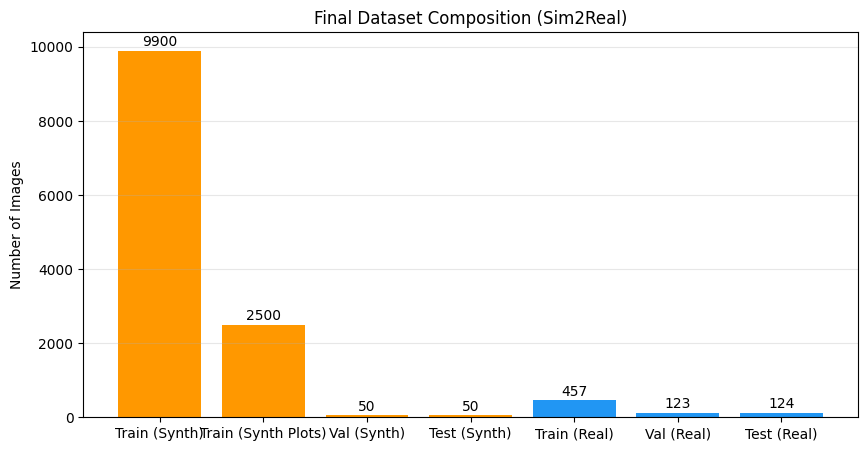

In [ ]:
# =============================================================================
# Visualize Dataset Composition
# Orange = Synthetic, Blue = Real
# =============================================================================
labels = [
    'Train (Synth Stitched)', 
    'Train (Synth Plots)', 
    'Val (Synth)', 
    'Test (Synth)', 
    'Train (Real)', 
    'Val (Real)', 
    'Test (Real)'
]
values = [
    len(map_synth_train), 
    len(map_synth_plots), 
    len(map_synth_val), 
    len(map_synth_test), 
    len(map_real_train), 
    len(map_real_val), 
    len(map_real_test)
]
colors = ['#FF9800', '#FFA726', '#FF9800', '#FF9800', '#2196F3', '#2196F3', '#2196F3']

plt.figure(figsize=(12, 5))
bars = plt.bar(labels, values, color=colors)
plt.title('Final Dataset Composition (V3: Sim2Real + Plot Augmentation)')
plt.ylabel('Number of Unique Images')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 8. Class Distribution Analysis

**Critical checkpoint!** After assembly, verify that:
1. No class has 0 samples in val/test (this broke V1)
2. Rare classes (4–7, 9) are present in all splits
3. The oversampling didn't introduce extreme imbalance

The heatmap and bar chart below show instance counts per class per split. Watch for:
- **Red flags:** Any cell with 0 in val or test columns
- **Yellow flags:** Extreme ratios (e.g., 50000:10 between train and val for a class)

Analysiere train: 15151 Bilder gelistet...
Analysiere val: 173 Bilder gelistet...
Analysiere test: 173 Bilder gelistet...

=== KLASSEN-VERTEILUNG (Instanzen via .txt File Lists) ===
               train  val  test  Total
Chart          16259  233   217  16709
Illustration    9062  107   100   9269
Image          14990  150   171  15311
Shared Legend   2320   15    16   2351
Shared Title    4047   20     9   4076
Shared X-Axis   6710   19    20   6749
Shared Y-Axis   5067   12    23   5102
Subpanel       20643  135   116  20894
Table           1339   54    55   1448

=== DATEI STATUS ===
TRAIN: Empty Labels (Background): 0 | Missing Label Files: 0
VAL: Empty Labels (Background): 0 | Missing Label Files: 0
TEST: Empty Labels (Background): 0 | Missing Label Files: 0


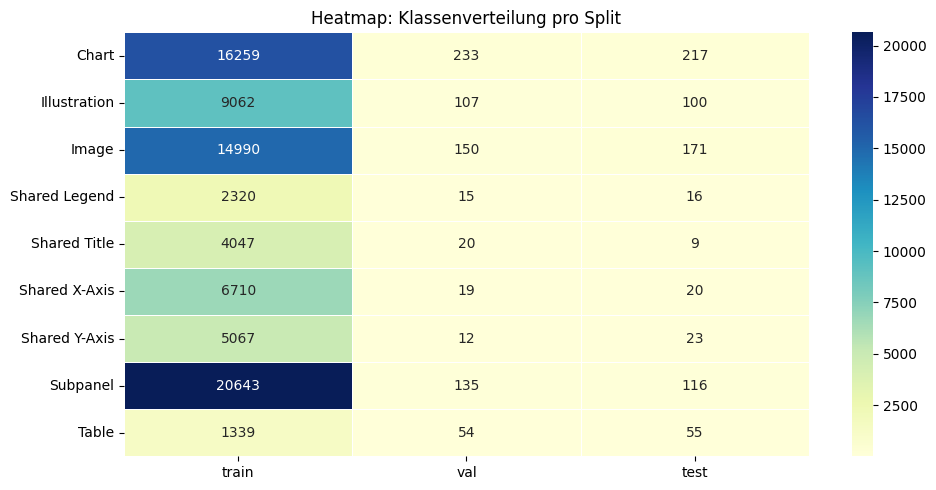

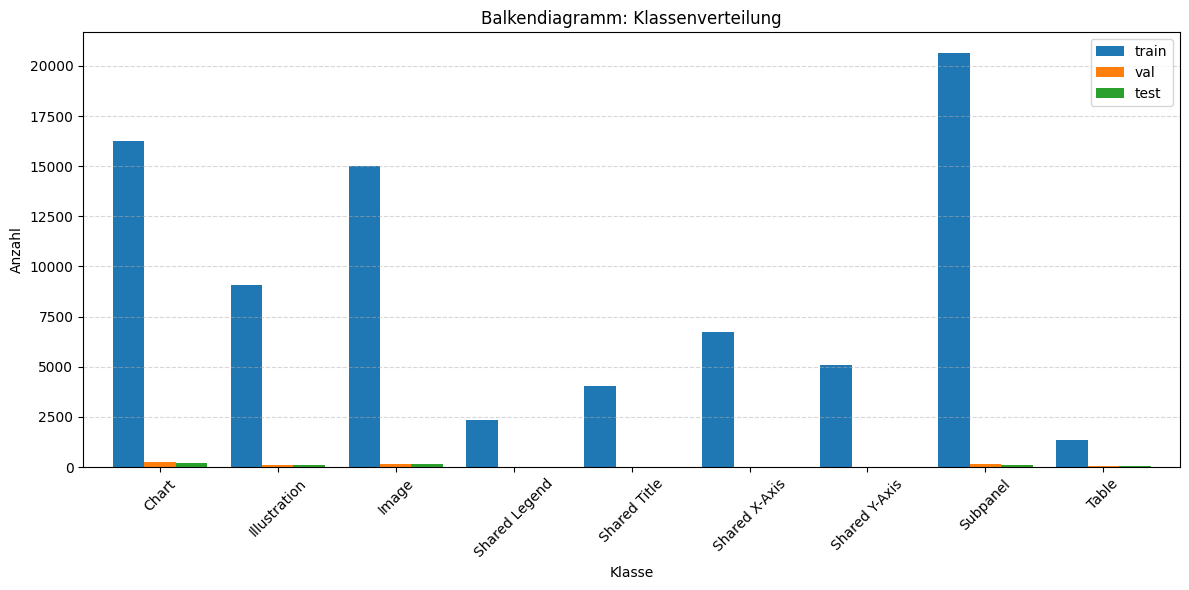

In [ ]:
# =============================================================================
# Class Distribution Analysis
# CRITICAL: Verify no class has 0 samples in val/test!
# =============================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Configuration
base_dir = "../../dataset/04_all_classes"
split_files = {
    'train': os.path.join(base_dir, "train.txt"),
    'val':   os.path.join(base_dir, "val.txt"),
    'test':  os.path.join(base_dir, "test.txt")
}

class_names = {
    0: 'Chart',
    1: 'Illustration',
    2: 'Image',
    3: 'Other',
    4: 'Shared Legend',
    5: 'Shared Title',
    6: 'Shared X-Axis',
    7: 'Shared Y-Axis',
    8: 'Subpanel',
    9: 'Table'
}

def image_path_to_label_path(img_path):
    """Convert image path to corresponding label path."""
    p = Path(img_path)
    parts = list(p.parts)
    try:
        # Find 'images' folder and replace with 'labels'
        idx = len(parts) - 1 - parts[::-1].index("images")
        parts[idx] = "labels"
    except ValueError:
        pass
    return Path(*parts).with_suffix('.txt')

def analyze_split_file(split_name, file_path):
    """Count class instances from a manifest file."""
    cnt = Counter()
    files_without_labels = 0
    missing_files = 0
    
    if not os.path.exists(file_path):
        print(f"Skipping {split_name}: File '{file_path}' not found.")
        return cnt, 0, 0

    with open(file_path, 'r') as f:
        img_paths = [line.strip() for line in f.readlines() if line.strip()]

    print(f"Analyzing {split_name}: {len(img_paths)} images listed...")

    for img_path in img_paths:
        label_path = image_path_to_label_path(img_path)
        
        if not os.path.exists(label_path):
            missing_files += 1
            continue

        with open(label_path, 'r') as f:
            lines = f.readlines()
            if not lines:
                files_without_labels += 1
            for line in lines:
                try:
                    class_id = int(line.split()[0])
                    cnt[class_id] += 1
                except (ValueError, IndexError):
                    pass

    return cnt, files_without_labels, missing_files

# Run analysis
stats = {}
empty_stats = {}
missing_stats = {}

for split, path in split_files.items():
    counts, empty, missing = analyze_split_file(split, path)
    if counts or empty or missing:
        stats[split] = counts
        empty_stats[split] = empty
        missing_stats[split] = missing

# Display results
if stats:
    df = pd.DataFrame(stats).fillna(0).astype(int)
    df.index = df.index.map(class_names)
    df = df.sort_index()
    df['Total'] = df.sum(axis=1)

    print("\n" + "="*60)
    print("CLASS DISTRIBUTION (Instance Counts)")
    print("="*60)
    print(df)

    print("\n" + "="*60)
    print("FILE STATUS")
    print("="*60)
    for split in stats.keys():
        print(f"{split.upper()}: Empty labels: {empty_stats[split]} | Missing: {missing_stats[split]}")

    # Check for zeros in val/test (RED FLAG!)
    for col in ['val', 'test']:
        if col in df.columns:
            zeros = df[df[col] == 0].index.tolist()
            if zeros:
                print(f"\n⚠️  WARNING: Classes with 0 samples in {col}: {zeros}")

    # Visualizations
    plot_df = df.drop(columns=['Total'])

    # Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(plot_df, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
    plt.title("Heatmap: Class Distribution per Split")
    plt.tight_layout()
    plt.show()

    # Bar Chart
    plot_df.plot(kind='bar', figsize=(14, 6), width=0.8)
    plt.title("Bar Chart: Class Distribution")
    plt.ylabel("Instance Count")
    plt.xlabel("Class")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='Split')
    plt.tight_layout()
    plt.show()
else:
    print("No data found. Check paths in 'split_files'.")

---

# Alternative Dataset: 05_selected_classes (5 classes)

This section creates a **reduced-class dataset** for experiments focusing only on main panel types:
- Chart (0), Illustration (1), Image (2), Other (3), Table (4)

**Why a reduced set?**
- Faster training iterations
- Simpler evaluation metrics
- Useful for comparing against baselines that don't support 10 classes

The mapping remaps Table from ID 9 → ID 4 to keep IDs contiguous.

In [27]:
import shutil
import random
import os
from pathlib import Path
from tqdm.notebook import tqdm
import yaml
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

## 1. Configuration & Paths (05_selected_classes)

Same source data, different output directory and class mapping.

**Key difference from 04_all_classes:**
- Labels are **remapped** during copy: only classes 0, 1, 2, 3, 9 are kept
- Classes 4–8 (shared elements, subpanels) are **dropped** from label files
- Table (ID 9) is remapped to ID 4 to keep IDs contiguous (0–4)

| Old ID | Old Name       | New ID | Kept? |
|--------|----------------|--------|-------|
| 0      | Chart          | 0      | ✅    |
| 1      | Illustration   | 1      | ✅    |
| 2      | Image          | 2      | ✅    |
| 3      | Other          | 3      | ✅    |
| 4–8    | Shared*/Subpanel | —    | ❌    |
| 9      | Table          | 4      | ✅    |

In [ ]:
# =============================================================================
# Configuration for 05_selected_classes (reduced 5-class dataset)
# =============================================================================

# --- INPUT PATHS (same sources as 04_all_classes) ---
SYNTH_DIR = Path("../../dataset/03_intermediate/SCI-3000_synthetic-generated")
SYNTH_IMG_DIR = SYNTH_DIR / "images"
SYNTH_LBL_DIR = SYNTH_DIR / "yolo-labels"

REAL_BASE_DIR = Path("../../dataset/03_intermediate/SCI-3000_real-compound")
REAL_IMG_DIR = REAL_BASE_DIR
REAL_LBL_DIR = REAL_BASE_DIR / "label-studio_export/labels"

SYNTH_PLOT_DIR = Path("../../dataset/03_intermediate/SyntheticCompoundPlots")
SYNTH_PLOT_IMG_DIR = SYNTH_PLOT_DIR / "images"
SYNTH_PLOT_LBL_DIR = SYNTH_PLOT_DIR / "yolo-labels"

# --- OUTPUT TARGET ---
OUTPUT_DIR = Path("../../dataset/05_selected_classes")

# --- CLASS MAPPING LOGIC ---
# Old ID -> New ID
# Keep only: Chart(0), Illustration(1), Image(2), Other(3), Table(9)
# Table(9) becomes ID 4 to maintain contiguous IDs 0-4
TARGET_CLASS_MAPPING = {
    0: 0,  # Chart -> Chart
    1: 1,  # Illustration -> Illustration
    2: 2,  # Image -> Image
    3: 3,  # Other -> Other
    9: 4   # Table -> remapped to ID 4
}

# --- SPLIT RATIOS ---
VAL_RATIO = 0.25   # 25% validation
TEST_RATIO = 0.10  # 10% test

# --- Helper Setup ---
def clear_and_create_dirs(base_path):
    """Remove existing directory and recreate empty train/val/test structure."""
    if base_path.exists():
        print(f"Cleaning up old directory: {base_path}")
        shutil.rmtree(base_path)
    
    for split in ['train', 'val', 'test']:
        (base_path / "images" / split).mkdir(parents=True, exist_ok=True)
        (base_path / "labels" / split).mkdir(parents=True, exist_ok=True)
    print(f"Directory structure created at {base_path}")

def find_image(stem, search_dirs):
    """Find image file by stem name across multiple directories."""
    valid_exts = ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']
    for folder in search_dirs:
        if not folder.exists(): continue
        for ext in valid_exts:
            p = folder / (stem + ext)
            if p.exists():
                return p
    return None

print("Config loaded. Mapping defined.")

Config loaded. Mapping defined.


## 2. Helper Functions

Core function to process files: finds images, **filters** labels (keeping only selected classes), **remaps** class IDs, and copies to output.

**Important behavior:**
- Images with **no** relevant classes (after filtering) are still copied as **background/negative samples**
- This helps the model learn what is *not* a target class

In [ ]:
def process_and_copy_files(unique_stems, search_img_dirs, src_lbl_dir, split_name):
    """
    Find images, filter labels based on TARGET_CLASS_MAPPING, and save both.
    
    This function:
    1. Finds the image file matching each stem
    2. Reads the corresponding label file
    3. FILTERS: Keeps only lines with class IDs in TARGET_CLASS_MAPPING
    4. REMAPS: Converts old IDs to new IDs (e.g., 9 -> 4 for Table)
    5. Saves the image and filtered/remapped label
    
    Args:
        unique_stems: List of file stems to process
        search_img_dirs: Directories to search for images
        src_lbl_dir: Directory containing label files
        split_name: 'train', 'val', or 'test'
    
    Returns:
        dict: Mapping of stem -> full output path
    """
    img_dest_dir = OUTPUT_DIR / "images" / split_name
    lbl_dest_dir = OUTPUT_DIR / "labels" / split_name
    path_map = {}
    
    count_copied = 0
    
    for stem in tqdm(unique_stems, desc=f"Processing {split_name}"):
        if isinstance(stem, Path): stem = stem.stem
        else: stem = str(stem)

        # 1. Find image
        img_path = find_image(stem, search_img_dirs)
        if not img_path: continue

        # 2. Find label
        lbl_path = src_lbl_dir / f"{stem}.txt"
        if not lbl_path.exists(): continue

        # 3. PROCESS LABEL (Filter & Remap)
        new_lines = []
        has_relevant_content = False
        
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if not parts: continue
            
            try:
                old_id = int(parts[0])
                # Only keep if defined in mapping
                if old_id in TARGET_CLASS_MAPPING:
                    new_id = TARGET_CLASS_MAPPING[old_id]
                    # Rebuild line with new ID
                    new_line = f"{new_id} " + " ".join(parts[1:])
                    new_lines.append(new_line)
                    has_relevant_content = True
            except ValueError:
                continue
        
        # IMPORTANT: We also save images without relevant labels (as background images).
        # You can add 'if has_relevant_content:' to skip empty images.
        # For this dataset, having background images (negative samples) is beneficial.
        
        # 4. Save files
        shutil.copy(img_path, img_dest_dir / img_path.name)
        
        with open(lbl_dest_dir / f"{stem}.txt", "w") as f_out:
            if new_lines:
                f_out.write("\n".join(new_lines))
            # Empty file is created if no relevant classes (background image)

        full_path = (img_dest_dir.resolve() / img_path.name)
        path_map[stem] = str(full_path)
        count_copied += 1

    return path_map

## 3. Data Collection & Splitting

**Special handling for Tables (class 9):**
Tables are extremely rare in the real data (often just 1–2 images). To ensure they appear in all splits:
1. Identify all images containing tables
2. Split the *other* images normally
3. **Clone** table images into train, val, AND test

This "manual injection" ensures the model sees tables during validation and testing.

In [ ]:
# =============================================================================
# Real Data Analysis & Manual Table Distribution
# =============================================================================
real_txts = list(REAL_LBL_DIR.glob("*.txt"))
data = []
search_img_real = [REAL_IMG_DIR, REAL_BASE_DIR / "label-studio_export"]

print(f"Analyzing {len(real_txts)} real label files...")

# List to store 'problem images' (containing tables)
table_stems = []

for txt_path in tqdm(real_txts, desc="Scanning Labels"):
    if txt_path.name == "classes.txt": continue
    
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        
    classes = []
    for line in lines:
        try:
            classes.append(int(line.split()[0]))
        except: continue
    
    unique_classes = set(classes)
    
    # Check Table presence (ID 9)
    has_table = 9 in unique_classes
    
    if has_table:
        # Store this filename separately!
        print(f"Found Table in: {txt_path.stem}")
        table_stems.append(txt_path.stem)
        # Set stratify_group to -1 for easy filtering later
        stratify_group = -1 
    else:
        # Group 0 is the normal rest
        stratify_group = 0
        
    data.append({
        'stem': txt_path.stem,
        'stratify_group': stratify_group,
        'is_table': has_table
    })

df = pd.DataFrame(data)

# 1. Separate tables from the rest
df_tables = df[df['is_table'] == True]
df_others = df[df['is_table'] == False]

print(f"Split Logic: {len(df_others)} normal images, {len(df_tables)} table images.")

# 2. Split ONLY the normal images (df_others)
# Since all are in group 0, stratify isn't strictly necessary here,
# but we keep it for consistency.
train_df, test_val_df = train_test_split(
    df_others, test_size=(VAL_RATIO + TEST_RATIO), random_state=42
)
val_df, test_df = train_test_split(
    test_val_df, test_size=0.5, random_state=42
)

# 3. MANUAL INJECTION: Add table(s) to ALL sets
# pd.concat appends the table image rows to the bottom of each dataframe.
if not df_tables.empty:
    print(f"Injecting tables: Adding {len(df_tables)} table images to Train, Val AND Test.")
    train_df = pd.concat([train_df, df_tables])
    val_df   = pd.concat([val_df, df_tables])
    test_df  = pd.concat([test_df, df_tables])

print(f"Final Real Split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Analysiere 704 reale Label-Dateien...


Scanning Labels:   0%|          | 0/704 [00:00<?, ?it/s]

Found Table in: 0d31e54afb194c7d80037e97eafe9167-5-fig-0
Split Logic: 703 normale Bilder, 1 Tabellen-Bilder.
Iniziere Tabellen-Klonen: Füge 1 Tabellen zu Train, Val UND Test hinzu.
Final Real Split: Train=457, Val=124, Test=125


In [ ]:
# =============================================================================
# Synthetic Data: Separate tables from other content
# Move some synthetic tables to val/test for better coverage
# =============================================================================
all_synth_txts = list(SYNTH_LBL_DIR.glob("*.txt"))
synth_tables = []
synth_others = []

for p in tqdm(all_synth_txts, desc="Scanning Synth Labels"):
    is_table = False
    with open(p, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts and parts[0] == '9':  # ID 9 is Table
                is_table = True
                break
    
    if is_table:
        synth_tables.append(p.stem)
    else:
        synth_others.append(p.stem)

# Move some synthetic tables to val/test (max 50, or 1/3 of available)
num_to_move = min(50, len(synth_tables) // 3) 
random.shuffle(synth_tables)

synth_val_stems = synth_tables[:num_to_move]
synth_test_stems = synth_tables[num_to_move : num_to_move*2]
synth_train_stems = synth_tables[num_to_move*2:] + synth_others

print(f"Synth Tables -> Val: {len(synth_val_stems)}, Test: {len(synth_test_stems)}")

Scanning Synth Labels:   0%|          | 0/10000 [00:00<?, ?it/s]

Synth Tables -> Val: 50, Test: 50


## 4. Execution: Copy Files

Physically merging files into `05_selected_classes`.

**Oversampling strategy:**
- Table images in training are duplicated **10×** to help the model learn this rare class
- All synthetic plots are added to training only
- Manifest files reflect the oversampling (multiple entries for the same image)

In [ ]:
# =============================================================================
# Execution: Copy and process all files
# =============================================================================
clear_and_create_dirs(OUTPUT_DIR)

# --- A. BUILD TRAINING LIST WITH OVERSAMPLING ---
train_stems_weighted = []

# Real Data: Oversample tables (the ones we just injected)
for _, row in train_df.iterrows():
    if row['is_table']: 
        # FOR TRAINING: Create 10 copies of the table entry
        # This helps the model learn this rare class
        train_stems_weighted.extend([row['stem']] * 10)
    else:
        train_stems_weighted.append(row['stem'])

# Add synthetic data
train_stems_weighted.extend(synth_train_stems)

# Add synthetic plots
synth_plots = list(SYNTH_PLOT_LBL_DIR.glob("*.txt"))
synth_plots_stems = [p.stem for p in synth_plots]
train_stems_weighted.extend(synth_plots_stems)

random.shuffle(train_stems_weighted)

# --- B. PROCESS & COPY ---
# Now use the lists that include the cloned tables
# 1. Real data
map_real_train = process_and_copy_files(train_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'train')
map_real_val   = process_and_copy_files(val_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'val')
map_real_test  = process_and_copy_files(test_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'test')

# 2. Synthetic SCI-3000
map_synth_train = process_and_copy_files(synth_train_stems, [SYNTH_IMG_DIR], SYNTH_LBL_DIR, 'train')
map_synth_val   = process_and_copy_files(synth_val_stems, [SYNTH_IMG_DIR], SYNTH_LBL_DIR, 'val')
map_synth_test  = process_and_copy_files(synth_test_stems, [SYNTH_IMG_DIR], SYNTH_LBL_DIR, 'test')

# 3. Synthetic plots (training only)
map_synth_plots = process_and_copy_files(synth_plots_stems, [SYNTH_PLOT_IMG_DIR], SYNTH_PLOT_LBL_DIR, 'train')

# Merge all maps
full_train_map = {**map_real_train, **map_synth_train, **map_synth_plots}
full_val_map   = {**map_real_val, **map_synth_val}
full_test_map  = {**map_real_test, **map_synth_test}

# --- C. CREATE MANIFEST TXT FILES ---
def write_manifest(filename, stem_list, lookup_map):
    """Write manifest file with paths for each stem in the list."""
    out_path = OUTPUT_DIR / filename
    valid_lines = []
    for stem in stem_list:
        if stem in lookup_map:
            valid_lines.append(lookup_map[stem])
    with open(out_path, 'w') as f:
        f.write('\n'.join(valid_lines))
    return len(valid_lines)

# Build val and test lists (now including the cloned real tables)
val_stems_comb = val_df['stem'].tolist() + synth_val_stems
test_stems_comb = test_df['stem'].tolist() + synth_test_stems

n_t = write_manifest('train.txt', train_stems_weighted, full_train_map)
n_v = write_manifest('val.txt', val_stems_comb, full_val_map)
n_te = write_manifest('test.txt', test_stems_comb, full_test_map)

print(f"Selected Classes Dataset Ready! Train: {n_t}, Val: {n_v}, Test: {n_te}")

Directory structure created at ../../dataset/05_selected_classes


Processing train:   0%|          | 0/457 [00:00<?, ?it/s]

Processing val:   0%|          | 0/124 [00:00<?, ?it/s]

Processing test:   0%|          | 0/125 [00:00<?, ?it/s]

Processing train:   0%|          | 0/9900 [00:00<?, ?it/s]

Processing val:   0%|          | 0/50 [00:00<?, ?it/s]

Processing test:   0%|          | 0/50 [00:00<?, ?it/s]

Processing train:   0%|          | 0/2500 [00:00<?, ?it/s]

Selected Classes Dataset Ready! Train: 12866, Val: 174, Test: 175


## 5. Create YAML Configuration

YOLO requires a `data.yaml` file specifying:
- Dataset path
- Train/val/test manifest files
- Class names with their IDs

Note the remapped class names: only 5 classes (0–4) instead of 10.

In [ ]:
# =============================================================================
# Create YAML configuration for YOLO
# Only 5 classes (remapped from original 10)
# =============================================================================
class_names_selected_classes = [
    "Chart",        # ID 0
    "Illustration", # ID 1
    "Image",        # ID 2
    "Other",        # ID 3
    "Table"         # ID 4 (was originally 9)
]

yaml_content = {
    'path': str(OUTPUT_DIR.resolve()),
    'train': 'train.txt',
    'val': 'val.txt',
    'test': 'test.txt',
    'names': {i: name for i, name in enumerate(class_names_selected_classes)}
}

with open(OUTPUT_DIR / "data.yaml", "w") as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"data.yaml for Selected Classes created in {OUTPUT_DIR}")

data.yaml für Selected Classes erstellt in ../../dataset/05_selected_classes


## 6. Delete Corrupted Files

Same corrupted files as in 04_all_classes (truncated images that crash the YOLO dataloader).

In [ ]:
# =============================================================================
# Delete corrupted files found during training
# These are truncated images that crash the YOLO dataloader
# =============================================================================
OUTPUT_DIR = Path("../../dataset/05_selected_classes")

corrupted_files = [
    "14d75f2b3d364548b43d84301c8687a4-6-fig-0",
    "0f132bfee79c4e87a9d4bd77215b685c-07-fig-1",
    "0f132bfee79c4e87a9d4bd77215b685c-07-fig-0"
]

possible_image_dirs = [
    OUTPUT_DIR / "images" / "train",
    OUTPUT_DIR / "images" / "val",
    OUTPUT_DIR / "images" / "test"
]

possible_label_dirs = [
    OUTPUT_DIR / "labels" / "train",
    OUTPUT_DIR / "labels" / "val",
    OUTPUT_DIR / "labels" / "test"
]

# Delete image and label files
for stem in corrupted_files:
    for img_dir in possible_image_dirs:
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']:
            img_path = img_dir / (stem + ext)
            if img_path.exists():
                img_path.unlink()
                print(f"Deleted corrupted image: {img_path}")
    for lbl_dir in possible_label_dirs:
        lbl_path = lbl_dir / (stem + ".txt")
        if lbl_path.exists():
            lbl_path.unlink()
            print(f"Deleted corrupted label: {lbl_path}")
    
# Remove entries from manifest files
for split in ['train.txt', 'val.txt', 'test.txt']:
    manifest_path = OUTPUT_DIR / split
    with open(manifest_path, 'r') as f:
        lines = f.readlines()
    
    with open(manifest_path, 'w') as f:
        for line in lines:
            if not any(stem in line for stem in corrupted_files):
                f.write(line)
    
    print(f"Updated {split} to remove corrupted entries.")

Deleted corrupted image: ../../dataset/05_selected_classes/images/train/14d75f2b3d364548b43d84301c8687a4-6-fig-0.png
Deleted corrupted label: ../../dataset/05_selected_classes/labels/train/14d75f2b3d364548b43d84301c8687a4-6-fig-0.txt
Deleted corrupted image: ../../dataset/05_selected_classes/images/train/0f132bfee79c4e87a9d4bd77215b685c-07-fig-1.png
Deleted corrupted label: ../../dataset/05_selected_classes/labels/train/0f132bfee79c4e87a9d4bd77215b685c-07-fig-1.txt
Deleted corrupted image: ../../dataset/05_selected_classes/images/train/0f132bfee79c4e87a9d4bd77215b685c-07-fig-0.png
Deleted corrupted label: ../../dataset/05_selected_classes/labels/train/0f132bfee79c4e87a9d4bd77215b685c-07-fig-0.txt
Updated train.txt to remove corrupted entries.
Updated val.txt to remove corrupted entries.
Updated test.txt to remove corrupted entries.


## 7. Class Distribution Analysis (05_selected_classes)

Verify that all 5 classes are present in train/val/test after filtering and remapping.

              train  val  test
Image         14222  159   134
Chart         13554  234   207
Illustration   8556  102   107
Table          1250   59    61


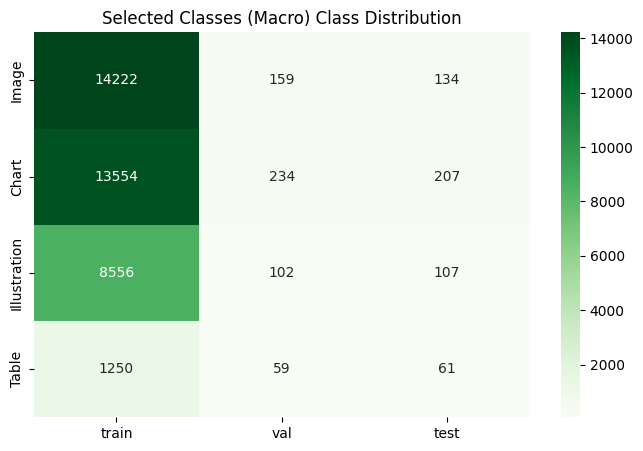

In [ ]:
# =============================================================================
# Class Distribution Analysis for 05_selected_classes
# =============================================================================
import seaborn as sns

# Config
base_dir = "../../dataset/05_selected_classes"
split_files = {
    'train': os.path.join(base_dir, "train.txt"),
    'val':   os.path.join(base_dir, "val.txt"),
    'test':  os.path.join(base_dir, "test.txt")
}

# New mapping for the plot (5 classes only)
class_names_plot = {
    0: 'Chart', 
    1: 'Illustration', 
    2: 'Image', 
    3: 'Other', 
    4: 'Table'
}

def analyze_split(file_path):
    """Count class instances from a manifest file."""
    cnt = Counter()
    if not os.path.exists(file_path): return cnt
    with open(file_path, 'r') as f:
        paths = [l.strip() for l in f]
    
    for p in paths:
        # Path trick: images -> labels, .png -> .txt
        lbl_p = Path(p.replace("/images/", "/labels/")).with_suffix(".txt")
        if lbl_p.exists():
            with open(lbl_p, 'r') as lf:
                for line in lf:
                    try:
                        cid = int(line.split()[0])
                        cnt[cid] += 1
                    except: pass
    return cnt

stats = {}
for split, p in split_files.items():
    stats[split] = analyze_split(p)

if stats:
    df_stats = pd.DataFrame(stats).fillna(0).astype(int)
    df_stats.index = df_stats.index.map(class_names_plot)
    
    print(df_stats)
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(df_stats, annot=True, fmt="d", cmap="Greens")
    plt.title("Selected Classes (5-class) Class Distribution")
    plt.show()

---

# Dataset 06: Compound Chart Splitter (5 classes)

This section creates a **specialized dataset** for splitting compound charts into subpanels.

**Purpose:** Train a model that, given a compound chart, detects:
- Subpanels (individual chart areas)
- Shared elements (legends, titles, axes)

**Key differences from 04/05:**
- **Strict filtering:** Only charts with compound elements, NO illustrations/tables/images
- **Class remapping:** Only classes 4–8 are kept, remapped to 0–4
- **Aggressive val/test ratios:** 30% val, 20% test (because we have very few real samples)

| Old ID | Old Name       | New ID | Purpose |
|--------|----------------|--------|---------|
| 4      | Shared Legend  | 0      | ✅ Kept |
| 5      | Shared Title   | 1      | ✅ Kept |
| 6      | Shared X-Axis  | 2      | ✅ Kept |
| 7      | Shared Y-Axis  | 3      | ✅ Kept |
| 8      | Subpanel       | 4      | ✅ Kept |
| 0,1,2,3,9 | Chart/Illust/etc | — | ❌ Dropped |

In [ ]:
# =============================================================================
# Dataset 06: Compound Chart Splitter
# =============================================================================
# This dataset contains ONLY charts with compound elements (subpanels, shared axes, etc.)
# Used to train a specialized model for splitting compound charts.
# 
# Strict filtering rules:
# - Must contain Chart (class 0)
# - Must NOT contain Illustration, Image, Other, or Table (classes 1, 2, 3, 9)
# - Must contain at least one compound element (classes 4-8)

## 1. Configuration & Paths (06_compound_chart_splitter)

## 2. Strict Real Data Filtering

**Filtering rules:**
1. **Must contain** Chart (class 0) - we only want chart images
2. **Must NOT contain** Illustration, Image, Other, Table (classes 1, 2, 3, 9) - no mixed content
3. **Must contain** at least one compound element (classes 4–8) - otherwise it's not compound

This produces a "pure" dataset of compound charts only.

**Stratification:** Images are grouped by their rarest compound element for balanced splitting.

In [ ]:
# =============================================================================
# Configuration for 06_compound_chart_splitter
# =============================================================================
import shutil
import random
import os
import math
from pathlib import Path
from tqdm.notebook import tqdm
import yaml
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

# --- INPUT PATHS ---
# Only using real compound charts and synthetic plots (no synthetic SCI-3000)
REAL_BASE_DIR = Path("../../dataset/03_intermediate/SCI-3000_real-compound")
REAL_IMG_DIR = REAL_BASE_DIR
REAL_LBL_DIR = REAL_BASE_DIR / "label-studio_export/labels"

SYNTH_PLOT_DIR = Path("../../dataset/03_intermediate/SyntheticCompoundPlots")
SYNTH_PLOT_IMG_DIR = SYNTH_PLOT_DIR / "images"
SYNTH_PLOT_LBL_DIR = SYNTH_PLOT_DIR / "yolo-labels"

# --- OUTPUT TARGET ---
OUTPUT_DIR = Path("../../dataset/06_compound_chart_splitter")

# --- CLASS MAPPING LOGIC ---
# Only keep compound-related classes, remap to 0-4
RELEVANT_CLASSES = [4, 5, 6, 7, 8]
SPLITTER_MAPPING = {
    4: 0,  # Shared Legend -> 0
    5: 1,  # Shared Title -> 1
    6: 2,  # Shared X-Axis -> 2
    7: 3,  # Shared Y-Axis -> 3
    8: 4   # Subpanel -> 4
}

# --- AGGRESSIVE SPLIT RATIOS (we have very few real samples) ---
VAL_RATIO = 0.30   # 30% Validation
TEST_RATIO = 0.20  # 20% Test
# Remaining 50% for Training (approximately 75 real images)

# --- Helper Functions ---
def clear_and_create_dirs(base_path):
    """Remove existing directory and recreate empty train/val/test structure."""
    if base_path.exists():
        print(f"Cleaning up: {base_path}")
        shutil.rmtree(base_path)
    for split in ['train', 'val', 'test']:
        (base_path / "images" / split).mkdir(parents=True, exist_ok=True)
        (base_path / "labels" / split).mkdir(parents=True, exist_ok=True)
    print(f"Directory structure created at {base_path}")

def find_image(stem, search_dirs):
    """Find image file by stem name across multiple directories."""
    valid_exts = ['.jpg', '.jpeg', '.png', '.JPG', '.PNG']
    for folder in search_dirs:
        if not folder.exists(): continue
        for ext in valid_exts:
            p = folder / (stem + ext)
            if p.exists(): return p
    return None

print("Config loaded. Ratios updated to 30% Val / 20% Test.")

Config loaded. Ratios updated to 30% Val / 20% Test.


In [ ]:
# =============================================================================
# Strict Real Data Filtering
# Only keep images that are pure compound charts
# =============================================================================

real_txts = list(REAL_LBL_DIR.glob("*.txt"))
data = []

# FILTER DEFINITIONS
# 1. Must have this (Chart)
REQUIRED_CLASS = 0 

# 2. Must NOT have any of these (Illustration, Image, Other, Table)
FORBIDDEN_CLASSES = {1, 2, 3, 9}

# 3. Must ALSO have at least one of these (Compound elements)
RELEVANT_COMPOUND_CLASSES = {4, 5, 6, 7, 8}

print(f"Scanning {len(real_txts)} real files...")
print("Filter rules: Only 'Chart' (0), no 'Illustration/Table' (1,2,3,9), must have compound elements.")

for txt_path in tqdm(real_txts):
    if txt_path.name == "classes.txt": continue
    
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        
    all_ids = set()
    for line in lines:
        try:
            all_ids.add(int(line.split()[0]))
        except: continue
    
    # --- CHECK 1: Forbidden classes? ---
    # If intersection with FORBIDDEN is not empty -> SKIP
    if not all_ids.isdisjoint(FORBIDDEN_CLASSES):
        continue

    # --- CHECK 2: Is it even a chart? ---
    if REQUIRED_CLASS not in all_ids:
        continue
        
    # --- CHECK 3: Does it have compound elements? ---
    if all_ids.isdisjoint(RELEVANT_COMPOUND_CLASSES):
        continue
        
    # If we're here, the image passes all filters!
    
    # Stratify Logic (Prioritize rare elements)
    if 5 in all_ids: strat_group = 5      # Shared Title (rarest)
    elif 4 in all_ids: strat_group = 4    # Shared Legend
    elif 6 in all_ids: strat_group = 6    # Shared X-Axis
    elif 7 in all_ids: strat_group = 7    # Shared Y-Axis
    else: strat_group = 8                 # Subpanel (most common)
    
    data.append({
        'stem': txt_path.stem,
        'stratify_group': strat_group
    })

df = pd.DataFrame(data)
print(f"\nRemaining Clean Compound Charts: {len(df)} (rest filtered out)")
print("Distribution by priority:")
print(df['stratify_group'].value_counts())

# Perform stratified split
# With very few samples, we need to be careful
if len(df) > 0:
    train_df, test_val_df = train_test_split(
        df, test_size=(VAL_RATIO + TEST_RATIO), stratify=df['stratify_group'], random_state=42
    )
    val_df, test_df = train_test_split(
        test_val_df, test_size=TEST_RATIO/(VAL_RATIO + TEST_RATIO), stratify=test_val_df['stratify_group'], random_state=42
    )
    print(f"Split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")
else:
    print("❌ WARNING: No images remaining! Filter too strict?")

Scanne 704 reale Dateien...
Filter-Regeln: Nur 'Chart' (0), keine 'Illustration/Table' (1,2,3,9), muss Compound-Elemente haben.


  0%|          | 0/704 [00:00<?, ?it/s]


Verbleibende Saubere Compound-Charts: 114 (Rest gefiltert)
Verteilung nach Priorität:
stratify_group
6    42
4    36
5    17
7    13
8     6
Name: count, dtype: int64
Split: Train=57, Val=34, Test=23


## 3. Dataset Creation (Strict Mode)

Copy files with:
1. **Redundant safety checks** during copy (belt and suspenders)
2. **Class remapping** from 4–8 to 0–4
3. **Heavy oversampling** (20×) of real data to balance against synthetic

In [ ]:
# =============================================================================
# Dataset Creation (Strict Mode)
# =============================================================================

search_img_real = [REAL_IMG_DIR, REAL_BASE_DIR / "label-studio_export"]

def process_and_copy_splitter(unique_stems, search_img_dirs, src_lbl_dir, split_name):
    """
    Copy files for the compound chart splitter dataset.
    
    This function:
    1. Finds images and labels
    2. RE-VALIDATES filters (redundant but safe)
    3. REMAPS class IDs (4-8 -> 0-4)
    4. Copies only compound-related annotations
    
    Args:
        unique_stems: List of file stems to process
        search_img_dirs: Directories to search for images
        src_lbl_dir: Directory containing label files
        split_name: 'train', 'val', or 'test'
    
    Returns:
        int: Number of files successfully processed
    """
    img_dest = OUTPUT_DIR / "images" / split_name
    lbl_dest = OUTPUT_DIR / "labels" / split_name
    
    count = 0
    stem_list = list(unique_stems)
    
    # Check if we're processing synthetic data (different validation rules)
    is_synth = "SyntheticCompoundPlots" in str(search_img_dirs[0])
    
    for stem in tqdm(stem_list, desc=f"Creating {split_name}"):
        if isinstance(stem, Path): stem = stem.stem
        else: stem = str(stem)

        # 1. Find files
        img_path = find_image(stem, search_img_dirs)
        lbl_path = src_lbl_dir / f"{stem}.txt"
        
        if not img_path or not lbl_path.exists(): continue

        # 2. Read & Filter
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
            
        all_ids = set()
        parsed_lines = []
        
        for line in lines:
            parts = line.strip().split()
            if not parts: continue
            try:
                cid = int(parts[0])
                all_ids.add(cid)
                parsed_lines.append((cid, parts[1:]))  # ID and coordinates
            except: continue
            
        # --- SAFETY CHECKS (Redundant to filtering cell, but better safe than sorry) ---
        if not is_synth:
            # Must be a chart
            if 0 not in all_ids: continue
            # Must not contain illustration/table
            if not all_ids.isdisjoint({1, 2, 3, 9}): continue
            
        # 3. REMAP & WRITE
        new_lines_str = []
        for cid, coords in parsed_lines:
            # Only keep compound classes & remap
            if cid in SPLITTER_MAPPING:
                new_id = SPLITTER_MAPPING[cid]
                new_line = f"{new_id} " + " ".join(coords)
                new_lines_str.append(new_line)
        
        # Save (avoid duplicates)
        if new_lines_str:
            if not (img_dest / img_path.name).exists():
                shutil.copy(img_path, img_dest / img_path.name)
                with open(lbl_dest / f"{stem}.txt", "w") as f_out:
                    f_out.write("\n".join(new_lines_str))
            count += 1

    return count

# --- Execute ---
clear_and_create_dirs(OUTPUT_DIR)

# --- A. COPY FILES ---
print("Copying Real Data (Strictly Filtered)...")
process_and_copy_splitter(train_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'train')
process_and_copy_splitter(val_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'val')
process_and_copy_splitter(test_df['stem'].unique(), search_img_real, REAL_LBL_DIR, 'test')

print("Copying Synthetic Plots...")
synth_plots = list(SYNTH_PLOT_LBL_DIR.glob("*.txt"))
synth_stems = [p.stem for p in synth_plots]
process_and_copy_splitter(synth_stems, [SYNTH_PLOT_IMG_DIR], SYNTH_PLOT_LBL_DIR, 'train')


# --- B. MANIFEST & OVERSAMPLING ---
def create_manifest(filename, stems, split_folder):
    """Create manifest file with paths to all images."""
    img_folder = OUTPUT_DIR / "images" / split_folder
    valid_paths = []
    for stem in stems:
        for ext in ['.jpg', '.png', '.jpeg', '.JPG', '.PNG']:
            p = img_folder / (stem + ext)
            if p.exists():
                valid_paths.append(str(p.resolve()))
                break
    with open(OUTPUT_DIR / filename, 'w') as f:
        f.write('\n'.join(valid_paths))
    return len(valid_paths)

# Heavy oversampling (20×) to balance real vs synthetic
real_train_stems = train_df['stem'].tolist()
full_train_list = (real_train_stems * 20) + synth_stems
random.shuffle(full_train_list)

n_t = create_manifest('train.txt', full_train_list, 'train')
n_v = create_manifest('val.txt', val_df['stem'].tolist(), 'val')
n_te = create_manifest('test.txt', test_df['stem'].tolist(), 'test')

print(f"\nDATASET COMPLETE (STRICT MODE)!")
print(f"Train entries: {n_t}")
print(f"Val images:    {n_v}")
print(f"Test images:   {n_te}")

Directory structure created at ../../dataset/06_compound_chart_splitter
Kopiere Reale Daten (Strict Filtered)...


Creating train:   0%|          | 0/57 [00:00<?, ?it/s]

Creating val:   0%|          | 0/34 [00:00<?, ?it/s]

Creating test:   0%|          | 0/23 [00:00<?, ?it/s]

Kopiere Synthetische Plots...


Creating train:   0%|          | 0/2500 [00:00<?, ?it/s]


DATASET COMPLETE (STRICT MODE)!
Train Einträge: 3640
Val Bilder:     34
Test Bilder:    23


## 4. Create YAML Configuration

YOLO configuration with the 5 compound-related classes (remapped to 0–4).

In [ ]:
# =============================================================================
# Create YAML configuration for YOLO
# 5 compound-related classes (remapped from original IDs 4-8)
# =============================================================================
class_names_splitter = [
    "Shared Legend",  # 0 (was 4)
    "Shared Title",   # 1 (was 5)
    "Shared X-Axis",  # 2 (was 6)
    "Shared Y-Axis",  # 3 (was 7)
    "Subpanel"        # 4 (was 8)
]

yaml_content = {
    'path': str(OUTPUT_DIR.resolve()),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {i: name for i, name in enumerate(class_names_splitter)}
}

with open(OUTPUT_DIR / "data.yaml", "w") as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(f"data.yaml created in {OUTPUT_DIR}")

data.yaml erstellt in ../../dataset/06_compound_chart_splitter
